In [1]:
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
import pandas as pd 

In [2]:
train_path = f'data/descriptors/descriptors_df_train.pkl'
test_path = f'data/descriptors/descriptors_df_test.pkl'
# Load the train and test dataframes
train_descriptors = pd.read_pickle(train_path)
test_descriptors = pd.read_pickle(test_path)

# Fill NaNs
train_descriptors.fillna(0, inplace=True)

# Prepare features and targets
feature_cols = [col for col in train_descriptors.columns 
                if col not in ['graph_id', 'edge_source', 'edge_dest', 'is_causal']]

X_train = train_descriptors[feature_cols]
y_train = train_descriptors['is_causal']

clf = BalancedRandomForestClassifier(n_estimators=500,random_state=42, n_jobs=50)
clf.fit(X_train, y_train)

/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this

BalancedRandomForestClassifier(n_estimators=500, n_jobs=50, random_state=42)

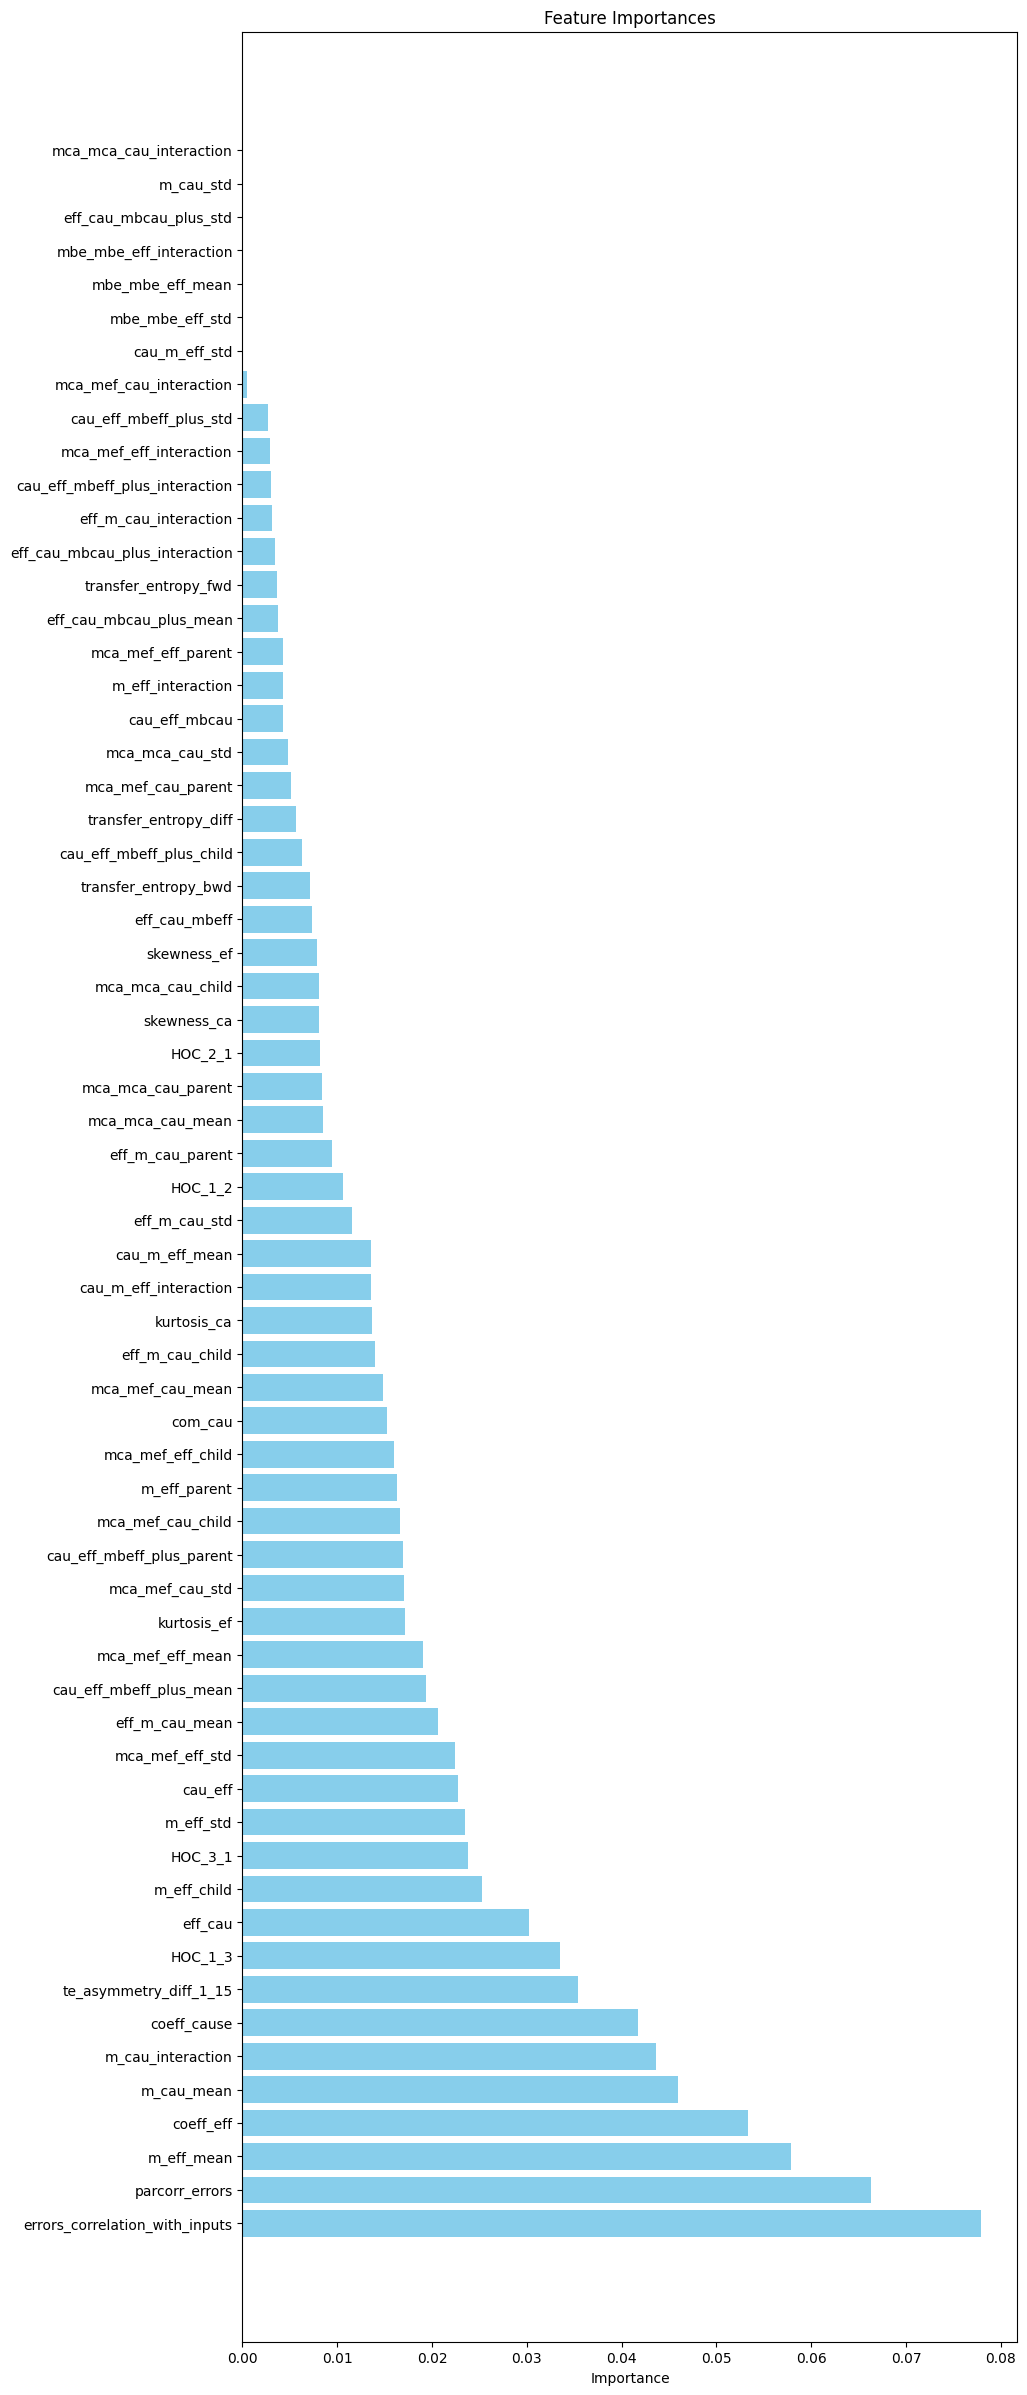

In [3]:
import matplotlib.pyplot as plt

# Get feature importances
importances = clf.feature_importances_

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 30))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()


In [ ]:
feature_importances.to_csv('feature_importances.csv', index=False)